## **COSMOLOGICAL CONSTRAINTS ON THE BARYON FRACTION IN THE IGM FROM FRB DATA WITH ΛCDM COSMOLOGY**

The goal is to constrain the baryon fraction in the IGM with LCDM cosmology using FRB dispersion measure

## **1. DATA PROCESSING**

The observed dispersion measure of a FRB is given by
$$
DM_{\rm obs}(z) = DM_{\rm MW} + DM_{\rm IGM}(z) + DM_{\rm host}(z),
$$
where the Milky Way contribution is
$$
DM_{\rm MW} = DM_{\rm MW,ISM} + DM_{\rm MW,halo}.
$$

Following the paper, they assume a constant Milky Way halo contribution
$$
DM_{\rm MW,halo} = 50\;{\rm pc\,cm^{-3}}.
$$

The observed **extragalactic** dispersion measure is defined as
$$
DM_{\rm ext}(z) \equiv DM_{\rm obs}(z) - DM_{\rm MW}.
$$

**16 localised FRBs** whose dispersion measures trace the electron column density along the line of sight

In [1]:
import pandas as pd
import numpy as np

# ---------------------------------------------------------------------------
# 1. Load FRB data
# ---------------------------------------------------------------------------

# FRB data link
url = "https://drive.google.com/uc?id=1icokvCOoPPHrQiLjxlAUyo_TXktPXAKb&export=download"

df = pd.read_csv(url)

df.head()

,Name,z,DM_MW_ISM,DM_obs,sigma_obs
0,FRB180916B,0.03370,200.0,348.80,0.2
1,FRB201124A,0.09800,123.2,413.52,0.5
2,FRB190608B,0.11780,37.2,338.70,0.5
3,FRB200430A,0.16000,27.0,380.25,0.4
4,FRB121102A,0.19273,188.0,557.00,2.0


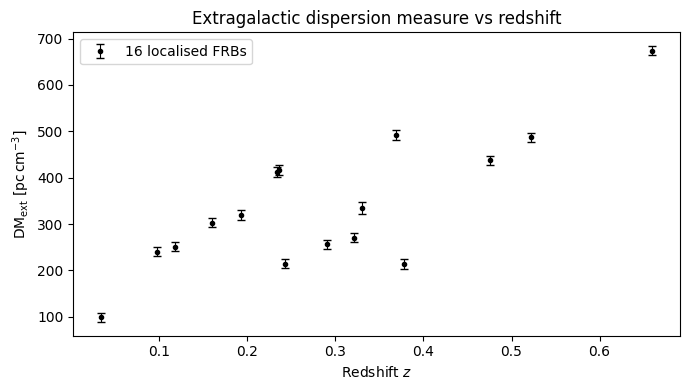

In [2]:
# ---------------------------------------------------------------------------
# 2. Derived quantities
# ---------------------------------------------------------------------------
DM_MW_HALO = 50.0   # pc cm^-3  — fixed halo contribution (§2.1 of paper)
SIGMA_MW   = 10.0   # pc cm^-3  — uncertainty on total DM_MW

df["DM_MW_halo"] = DM_MW_HALO
df["DM_MW"]      = df["DM_MW_ISM"] + DM_MW_HALO
df["DM_ext"]     = df["DM_obs"]    - df["DM_MW"]
df["sigma_MW"]   = SIGMA_MW
df["DM_ext_err"] = np.sqrt(df["sigma_obs"] ** 2 + SIGMA_MW ** 2)

DM_ext     = df["DM_ext"].values
z_frb      = df["z"].values
DM_ext_err = df["DM_ext_err"].values

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(z_frb, DM_ext, yerr=DM_ext_err,
            fmt='.k', capsize=3, elinewidth=0.8, label="16 localised FRBs")
ax.set_xlabel(r"Redshift $z$")
ax.set_ylabel(r"$\mathrm{DM}_{\rm ext}\ [\mathrm{pc\,cm^{-3}}]$")
ax.legend()
ax.set_title("Extragalactic dispersion measure vs redshift")
plt.tight_layout()
plt.show()

## **2. MODEL**

The theoretical extragalactic DM is the sum of the IGM and host galaxy contributions:

$$
\mathrm{DM}_{\rm ext}^{\rm th}(z) = \mathrm{DM}_{\rm IGM}(z) + \mathrm{DM}_{\rm host}(z).
$$

The host DM is redshifted into the observer frame:

$$
\mathrm{DM}_{\rm host}(z) = \frac{\mathrm{DM}_{\rm host,0}}{1+z}.
$$

In [3]:
def DM_host(z, DM_host_0):
    return DM_host_0 / (1 + z)

The IGM DM for a single FRB at redshift $z$ is (Lemos et al. Eq. 5):

$$
\mathrm{DM}_{\rm IGM}(z) = \frac{3c\,\Omega_b H_0^2}{8\pi G m_p}
\int_0^z \frac{(1+z^\prime)\,f_{\rm IGM}(z^\prime)\,\chi}{H(z^\prime)}\,dz^\prime,
\qquad \chi = \frac{7}{8}.
$$



**Fiducial cosmology.** Following the instruction to fix $\Omega_m$ and $H_0$ at
fiducial values, the values are set as:

$$
H_0 = 74.03\ \mathrm{km\,s^{-1}\,Mpc^{-1}}, \qquad \Omega_m = 0.315
$$

(SH0ES value for $H_0$ as in Lemos et al.; $\Omega_m$ from Planck 2018)

In [4]:
# Physical constants in SI
c    = 2.99792458e8               # m s^-1
G    = 6.67430e-11                # m^3 kg^-1 s^-2
mp   = 1.6726e-27                 # kg
H0   = 74.03e3 / 3.085677581e22  # s^-1
h    = 74.03 / 100
obh2 = 0.02235
om_b = obh2 / h**2
Om0  = 0.315 # Omega_m

A = (21 * c * om_b * H0**2) / (64 * np.pi * G * mp)

### Unit conversion

The SI prefactor $A$ gives $DM_{\rm IGM}$ in **m$^{-2}$**. We convert to **pc cm$^{-3}$** using
$$
1\;{\rm pc\,cm^{-3}} = \frac{3.085677581\times10^{16}\;{\rm m}}{(10^{-2}\;{\rm m})^3} = 3.085677581\times10^{22}\;{\rm m^{-2}},
$$
so dividing by this factor gives the result in pc cm$^{-3}$.

In [5]:
def to_pc_cm3(dm_m2):
    """Convert DM from m^-2 to pc cm^-3."""
    return dm_m2 / (3.085677581e16 / (1e-2)**3)

### $H(z)$ models


**$\Lambda$CDM** ($w = -1$):
$$H(z) = H_0\sqrt{\Omega_m(1+z)^3 + (1-\Omega_m)}$$

In [6]:
def H_LCDM(z):
  dark_energy = 1
  expr = (1+z)**3 * Om0 + (1-Om0) * dark_energy
  return H0 * np.sqrt(expr)

### Constant $f_{\rm IGM}$

$$f_{\rm IGM}(z) = f_{\rm IGM,0}$$

Substituting into the integrated form of Eq. 5 gives (Eq. 11):

$$
\mathrm{DM}_{\rm IGM}(z)
  = A\,f_{\rm IGM,0}
    \left[
      \frac{d_L(z)}{c} - \mathcal{I}(z)
    \right].
$$

Free parameters: $f_{\rm IGM,0}$, $\mathrm{DM}_{\rm host,0}$.

In [7]:
def f_IGM_const(z, f_IGM_0):
    return f_IGM_0

### Time-dependent $f_{\rm IGM}$

$$f_{\rm IGM}(z) = f_{\rm IGM,0} + \alpha\,\frac{z}{1+z}$$

where $\alpha \geq 0$ allows for a growing baryon fraction with redshift.

Free parameters: $f_{\rm IGM,0}$, $\alpha$, $\mathrm{DM}_{\rm host,0}$.

In [8]:
def f_IGM_timedep(z, f_IGM_0, alpha):
    return f_IGM_0 + alpha * (z / (1+z))

Now we compute the DM in the IGM as:

$$
\mathrm{DM}_{\rm IGM}(z) = A
\int_0^z \frac{(1+z^\prime)\,f_{\rm IGM}(z^\prime)}{H(z^\prime)}\,dz^\prime,
\qquad
A = \frac{21\,c\,\Omega_b H_0^2}{64\pi G m_p}.
$$


In [9]:
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d

def IGM_integrand(z, params, f_IGM_func):
  f_IGM = f_IGM_func(z, *params[:-1])
  return (1+z) * f_IGM / H_LCDM(z)

def DM_IGM(z_array, params, f_IGM_func):
  max_z = np.max(z_array)
  z_grid = np.linspace(0, max_z * 1.1, 500)

  # Calculate integrand values over the grid
  integrand_values = np.array([
        IGM_integrand(z, params, f_IGM_func)
        for z in z_grid
    ])

  # Perform cumulative integration
  cumulative_integral = cumulative_trapezoid(integrand_values, z_grid, initial=0.0)

  dm_grid = to_pc_cm3(A * cumulative_integral)

  # Interpolate to the desired z_array values
  interpolator = interp1d(z_grid, dm_grid, kind='cubic', fill_value="extrapolate", bounds_error=False)
  return interpolator(z_array)


### Unified theoretical model

In [10]:
def DM_ext_th(z, params, f_IGM_model):
  DM_host_0 = params[-1]
  return DM_IGM(z, params, f_IGM_model) + DM_host(z, DM_host_0)

## **3. BAYESIAN INFERENCE**

In [11]:
!pip install emcee corner

We adopt a Gaussian likelihood
$$
\ln\mathcal{L}(\boldsymbol{\theta}) = -\frac{1}{2}\sum_i\left(\frac{DM_{\rm ext,i} - DM_{\rm ext}^{\rm th}(z_i;\boldsymbol{\theta})}{\sigma_i}\right)^2,
$$

In [12]:

def log_likelihood(params, f_IGM_model):
  model = DM_ext_th(z_frb, params, f_IGM_model)
  return -0.5 * np.sum(
        ((DM_ext - model)/DM_ext_err)**2
    )

### Case A — Constant $f_{\rm IGM}$

In [13]:
def log_prior_const(params):
    f, D = params
    if 0.0 <= f <= 1.0 and 0.0 <= D <= 300.0:
        return 0.0
    return -np.inf

def log_prob_const(params):
  lp = log_prior_const(params)

  if not np.isfinite(lp):
      return -np.inf

  return lp + log_likelihood(params, f_IGM_const)


In [14]:
import emcee
import corner
import multiprocessing

## EMCEE SETUP
nDim_const = 2
nwalkers = 32

initial_guess = np.array([0.7, 150.0])
pos = initial_guess + np.array([0.05, 30.0]) * np.random.randn(nwalkers, nDim_const)
pos[:,0] = np.clip(pos[:,0], 0.01, 0.99)
pos[:,1] = np.clip(pos[:,1], 10.0, 499.0)

# ============================================================
# RUN MCMC with multiprocessing
# ============================================================
n_cores = multiprocessing.cpu_count()
with multiprocessing.Pool(processes=n_cores) as pool:
    sampler = emcee.EnsembleSampler(
        nwalkers,
        nDim_const,
        log_prob_const,
        pool=pool
    )

    print(f"Running MCMC with {n_cores} cores...")
    sampler.run_mcmc(pos, 2000, progress=True)
    print("Done.")


Running MCMC with 2 cores...


100%|██████████| 2000/2000 [03:36<00:00,  9.25it/s]

Done.


Result case A


===== RESULTS (Constant f_IGM) ===

f_IGM_0 = 0.778  +0.013  -0.013
DM_host_0 = 157.302  +5.309  -5.245


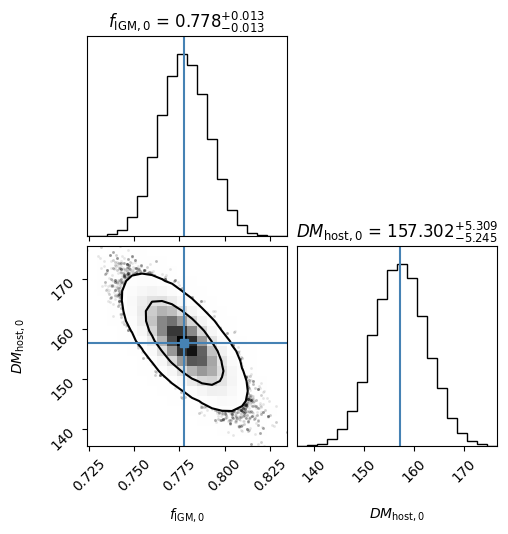

In [15]:
tau = sampler.get_autocorr_time()
burn = int(2 * np.max(tau))
samples_const = sampler.get_chain(discard=burn, flat=True)

f_IGM_0_mcmc = np.percentile(samples_const[:,0], [16,50,84])
DM_host_0_mcmc = np.percentile(samples_const[:,1], [16,50,84])

print("\n===== RESULTS (Constant f_IGM) ===\n")

print(
    f"f_IGM_0 = {f_IGM_0_mcmc[1]:.3f} "
    f" +{f_IGM_0_mcmc[2]-f_IGM_0_mcmc[1]:.3f} "
    f" -{f_IGM_0_mcmc[1]-f_IGM_0_mcmc[0]:.3f}"
)

print(
    f"DM_host_0 = {DM_host_0_mcmc[1]:.3f} "
    f" +{DM_host_0_mcmc[2]-DM_host_0_mcmc[1]:.3f} "
    f" -{DM_host_0_mcmc[1]-DM_host_0_mcmc[0]:.3f}"
)

fig = corner.corner(
    samples_const,
    labels=[r"$f_{\rm IGM,0}$", r"$DM_{\rm host,0}$"],
    truths=[f_IGM_0_mcmc[1], DM_host_0_mcmc[1]],
    show_titles=True,
    title_fmt=".3f",
    levels=(0.68, 0.95),
    smooth=1.0
)

### Case B — Time-dependent $f_{\rm IGM}$

In [16]:
def log_prior_timedep(params):
    f_IGM_0, alpha, DM_host_0 = params

    if 0.0 <= f_IGM_0 <= 1.0 and 0.0 <= alpha <= 3.0 and 0.0 <= DM_host_0 <= 300.0:
        return 0.0
    return -np.inf

def log_prob_timedep(params):
  lp = log_prior_timedep(params)

  if not np.isfinite(lp):
      return -np.inf

  return lp + log_likelihood(params, f_IGM_timedep)

In [17]:
import emcee
import corner
import multiprocessing

## EMCEE SETUP for time-dependent f_IGM
nDim_timedep = 3
nwalkers_timedep = 32

initial_guess_timedep = np.array([0.7, 1, 150.0])
pos_timedep = initial_guess_timedep + np.array([0.05, 0.01, 30.0]) * np.random.randn(nwalkers_timedep, nDim_timedep)

# initial positions
pos_timedep[:,0] = np.clip(pos_timedep[:,0], 0.01, 0.99) # f_IGM_0
pos_timedep[:,1] = np.clip(pos_timedep[:,1], 0.0, 3.0)   # alpha 
pos_timedep[:,2] = np.clip(pos_timedep[:,2], 10.0, 299.0) # DM_host_0

# ============================================================
# RUN MCMC with multiprocessing for time-dependent f_IGM
# ============================================================
n_cores = multiprocessing.cpu_count()
with multiprocessing.Pool(processes=n_cores) as pool:
    sampler_timedep = emcee.EnsembleSampler(
        nwalkers_timedep,
        nDim_timedep,
        log_prob_timedep, # This function will be defined in the next cell
        pool=pool
    )

    print(f"Running MCMC for time-dependent f_IGM with {n_cores} cores...")
    sampler_timedep.run_mcmc(pos_timedep, 2000, progress=True)
    print("Done.")

Running MCMC for time-dependent f_IGM with 2 cores...


100%|██████████| 2000/2000 [03:53<00:00,  8.55it/s]


Done.


### Results for Case B — Time-dependent $f_{\rm IGM}$


===== RESULTS (Time-dependent f_IGM) ===

f_IGM_0 = 0.504  +0.062  -0.063
alpha = 1.198  +0.265  -0.268
DM_host_0 = 189.211  +9.131  -8.725


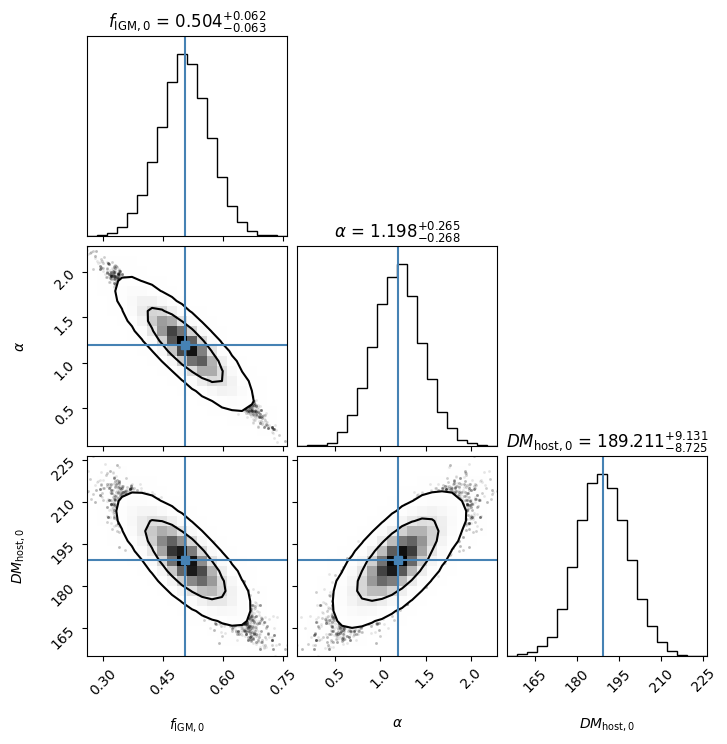

In [18]:
tau_timedep = sampler_timedep.get_autocorr_time()
burn_timedep = int(2 * np.max(tau_timedep))
samples_timedep = sampler_timedep.get_chain(discard=burn_timedep, flat=True)

f_IGM_0_mcmc_timedep = np.percentile(samples_timedep[:,0], [16,50,84])
alpha_mcmc_timedep = np.percentile(samples_timedep[:,1], [16,50,84])
DM_host_0_mcmc_timedep = np.percentile(samples_timedep[:,2], [16,50,84])

print("\n===== RESULTS (Time-dependent f_IGM) ===\n")

print(
    f"f_IGM_0 = {f_IGM_0_mcmc_timedep[1]:.3f} "
    f" +{f_IGM_0_mcmc_timedep[2]-f_IGM_0_mcmc_timedep[1]:.3f} "
    f" -{f_IGM_0_mcmc_timedep[1]-f_IGM_0_mcmc_timedep[0]:.3f}"
)

print(
    f"alpha = {alpha_mcmc_timedep[1]:.3f} "
    f" +{alpha_mcmc_timedep[2]-alpha_mcmc_timedep[1]:.3f} "
    f" -{alpha_mcmc_timedep[1]-alpha_mcmc_timedep[0]:.3f}"
)

print(
    f"DM_host_0 = {DM_host_0_mcmc_timedep[1]:.3f} "
    f" +{DM_host_0_mcmc_timedep[2]-DM_host_0_mcmc_timedep[1]:.3f} "
    f" -{DM_host_0_mcmc_timedep[1]-DM_host_0_mcmc_timedep[0]:.3f}"
)

fig_timedep = corner.corner(
    samples_timedep,
    labels=[r"$f_{\rm IGM,0}$", r"$\alpha$", r"$DM_{\rm host,0}$"],
    truths=[f_IGM_0_mcmc_timedep[1], alpha_mcmc_timedep[1], DM_host_0_mcmc_timedep[1]],
    show_titles=True,
    title_fmt=".3f",
    levels=(0.68, 0.95),
    smooth=1.0
)

## **4. MODEL COMPARISON**

Nested sampling method computes the Bayesian evidence:

$$
\mathcal{Z} = P(D|M),
$$

which allows direct model comparison through:

$$
\Delta \ln \mathcal{Z}
=
\ln \mathcal{Z}_{\rm evolving}
-
\ln \mathcal{Z}_{\rm constant}.
$$

Interpretation:

| $\Delta \ln \mathcal{Z}$ | Interpretation |
|---|---|
| $<1$ | inconclusive |
| $1-3$ | weak evidence |
| $3-5$ | moderate evidence |
| $>5$ | strong evidence |

In [19]:
!pip install dynesty -q

### Case A — Constant $f_{\rm IGM}$

In [20]:
from dynesty import NestedSampler

# Define likelihood function for dynesty (constant f_IGM)
def log_likelihood_const_dynesty(params):
    return log_likelihood(params, f_IGM_const)

# Define prior transform for dynesty (constant f_IGM)
def prior_transform_const(u):
    f_IGM_0_min, f_IGM_0_max = 0.0, 1.0 # From MCMC prior
    DM_host_0_min, DM_host_0_max = 0.0, 300.0 # From MCMC prior

    f_IGM_0 = u[0] * (f_IGM_0_max - f_IGM_0_min) + f_IGM_0_min
    DM_host_0 = u[1] * (DM_host_0_max - DM_host_0_min) + DM_host_0_min
    return [f_IGM_0, DM_host_0]


# Number of dimensions for constant f_IGM model
ndim_const = 2

# Initialize and run nested sampling for constant f_IGM
sampler_dynesty_const = NestedSampler(
    log_likelihood_const_dynesty,
    prior_transform_const,
    ndim_const,
    nlive=1000  # Number of live points
)
sampler_dynesty_const.run_nested(dlogz=0.01) # dlogz for convergence

results_dynesty_const = sampler_dynesty_const.results
print("\n--- Dynesty Results (Constant f_IGM) ---")
results_dynesty_const.summary()

11671it [02:36, 74.65it/s, +1000 | bound: 13 | nc: 1 | ncall: 49257 | eff(%): 26.257 | loglstar:   -inf < -553.854 <    inf | logz: -560.909 +/-  0.078 | dlogz:  0.000 >  0.010]


--- Dynesty Results (Constant f_IGM) ---
Summary
nlive: 1000
niter: 11671
ncall: 48257
eff(%): 26.257
logz: -560.909 +/-  0.080


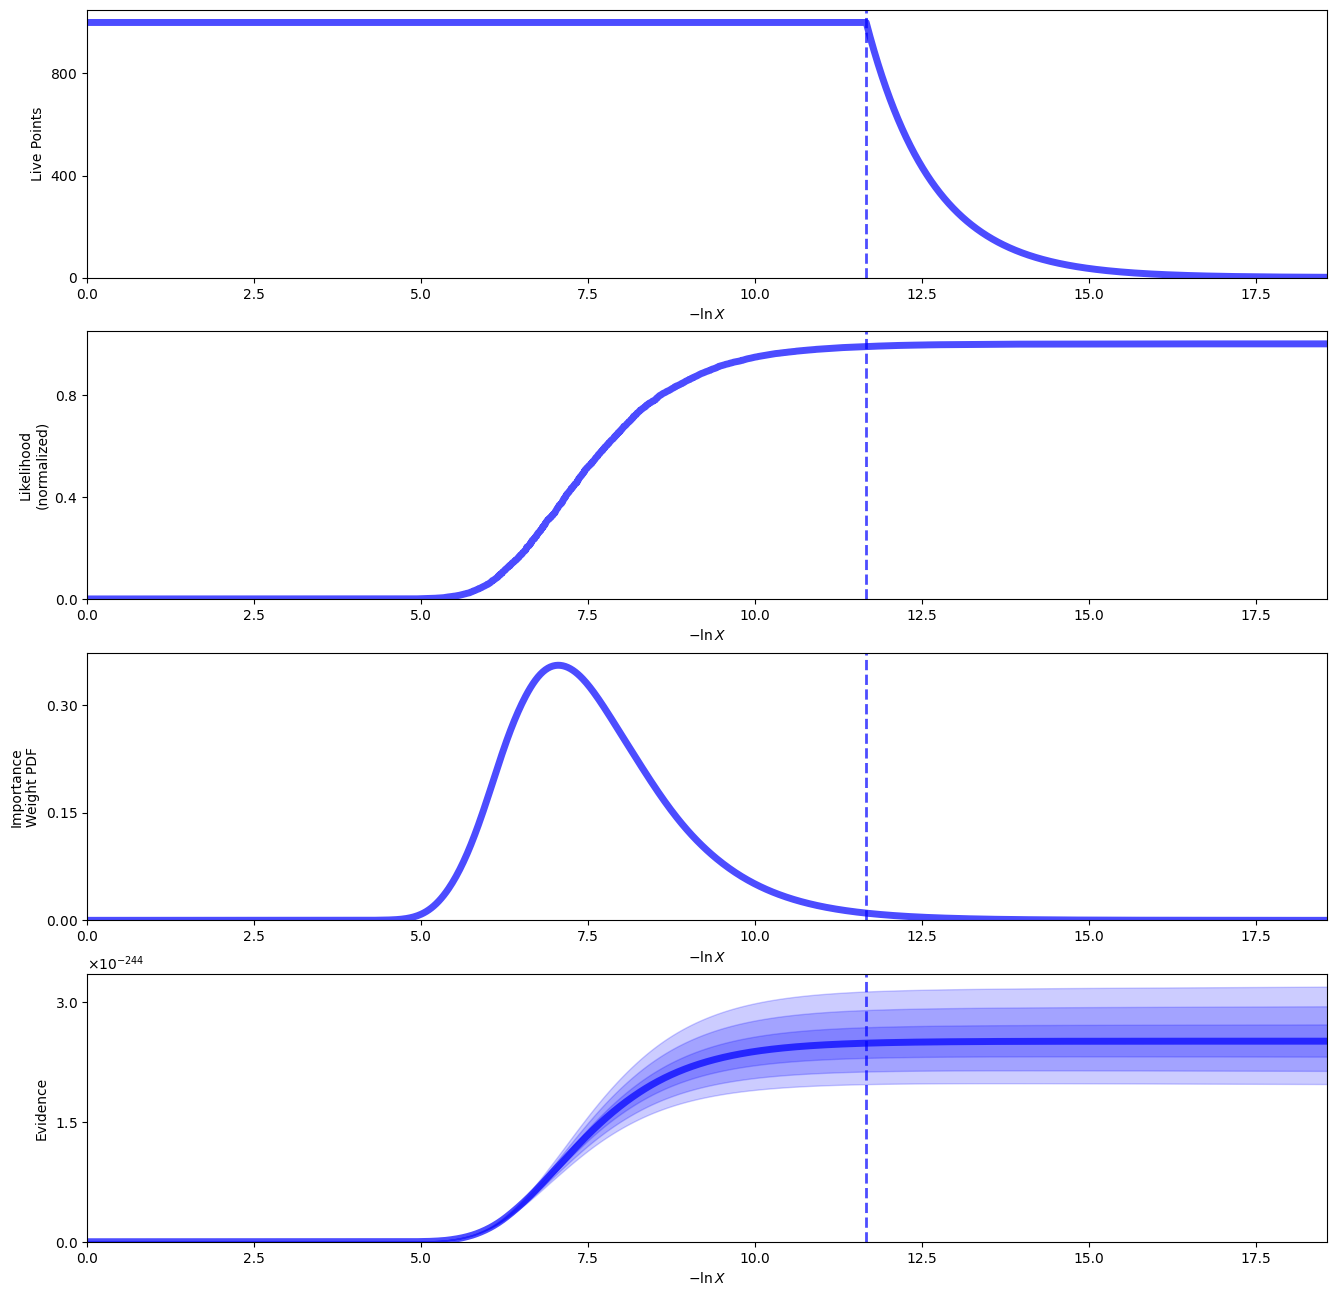

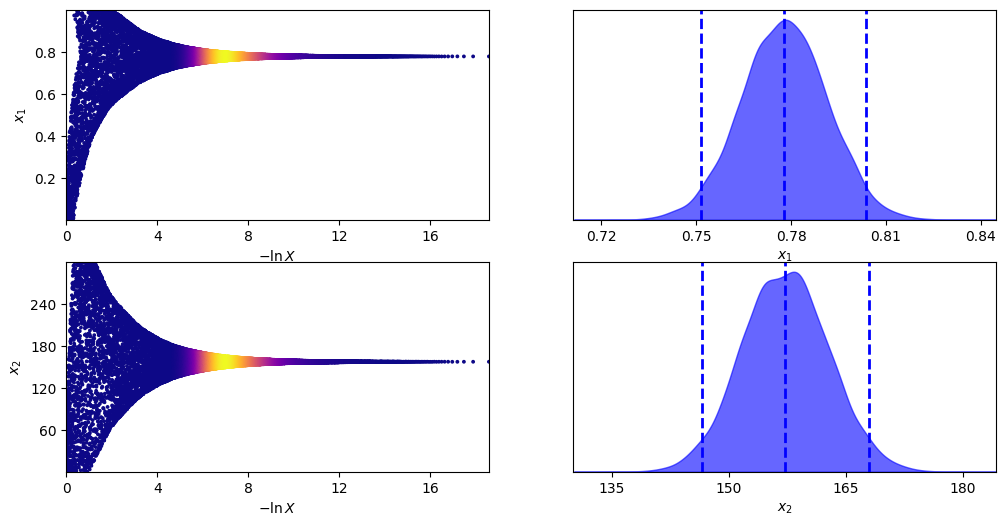

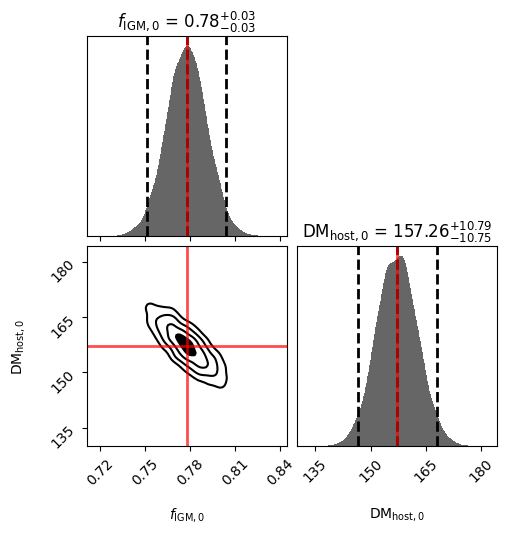

In [21]:
from dynesty import plotting as dyplot

# Runplot for constant f_IGM model
rfig_const, raxes_const = dyplot.runplot(results_dynesty_const)

# Traceplot for constant f_IGM model
tfig_const, taxes_const = dyplot.traceplot(results_dynesty_const)

# Get equally weighted samples from dynesty results for constant f_IGM model
samples_const_dynesty = results_dynesty_const.samples_equal()

# Define truths from dynesty samples for constant f_IGM model
f_med_const_dynesty = np.percentile(samples_const_dynesty[:, 0], 50)
D_med_const_dynesty = np.percentile(samples_const_dynesty[:, 1], 50)

# Cornerplot for constant f_IGM model
dffig_const, dfaxes_const = dyplot.cornerplot(results_dynesty_const,
                                  labels=[r"$f_{\rm IGM,0}$", r"$\mathrm{DM}_{\rm host,0}$"],
                                  truths=[f_med_const_dynesty, D_med_const_dynesty],
                                  show_titles=True)


### Case B — Time-dependent $f_{\rm IGM}$

In [22]:
from dynesty import NestedSampler

# Define likelihood function for dynesty (time-dependent f_IGM)
def log_likelihood_timedep_dynesty(params):
    return log_likelihood(params, f_IGM_timedep)

# Define prior transform for dynesty (time-dependent f_IGM)
def prior_transform_timedep(u):
    f_IGM_0_min, f_IGM_0_max = 0.0, 1.0
    alpha_min, alpha_max = 0.0, 3.0
    DM_host_0_min, DM_host_0_max = 0.0, 300.0

    f_IGM_0 = u[0] * (f_IGM_0_max - f_IGM_0_min) + f_IGM_0_min
    alpha = u[1] * (alpha_max - alpha_min) + alpha_min
    DM_host_0 = u[2] * (DM_host_0_max - DM_host_0_min) + DM_host_0_min
    return [f_IGM_0, alpha, DM_host_0]


# Number of dimensions for time-dependent f_IGM model
nDim_timedep_dynesty = 3

# Initialize and run nested sampling for time-dependent f_IGM
sampler_dynesty_timedep = NestedSampler(
    log_likelihood_timedep_dynesty,
    prior_transform_timedep,
    nDim_timedep_dynesty,
    nlive=1000  # Number of live points
)
sampler_dynesty_timedep.run_nested(dlogz=0.01) # dlogz for convergence

results_dynesty_timedep = sampler_dynesty_timedep.results
print("\n--- Dynesty Results (Time-dependent f_IGM) ---")
results_dynesty_timedep.summary()

13111it [02:54, 75.34it/s, +1000 | bound: 16 | nc: 1 | ncall: 51452 | eff(%): 27.969 | loglstar:   -inf < -544.027 <    inf | logz: -552.521 +/-  0.084 | dlogz:  0.000 >  0.010]


--- Dynesty Results (Time-dependent f_IGM) ---
Summary
nlive: 1000
niter: 13111
ncall: 50452
eff(%): 27.969
logz: -552.521 +/-  0.087


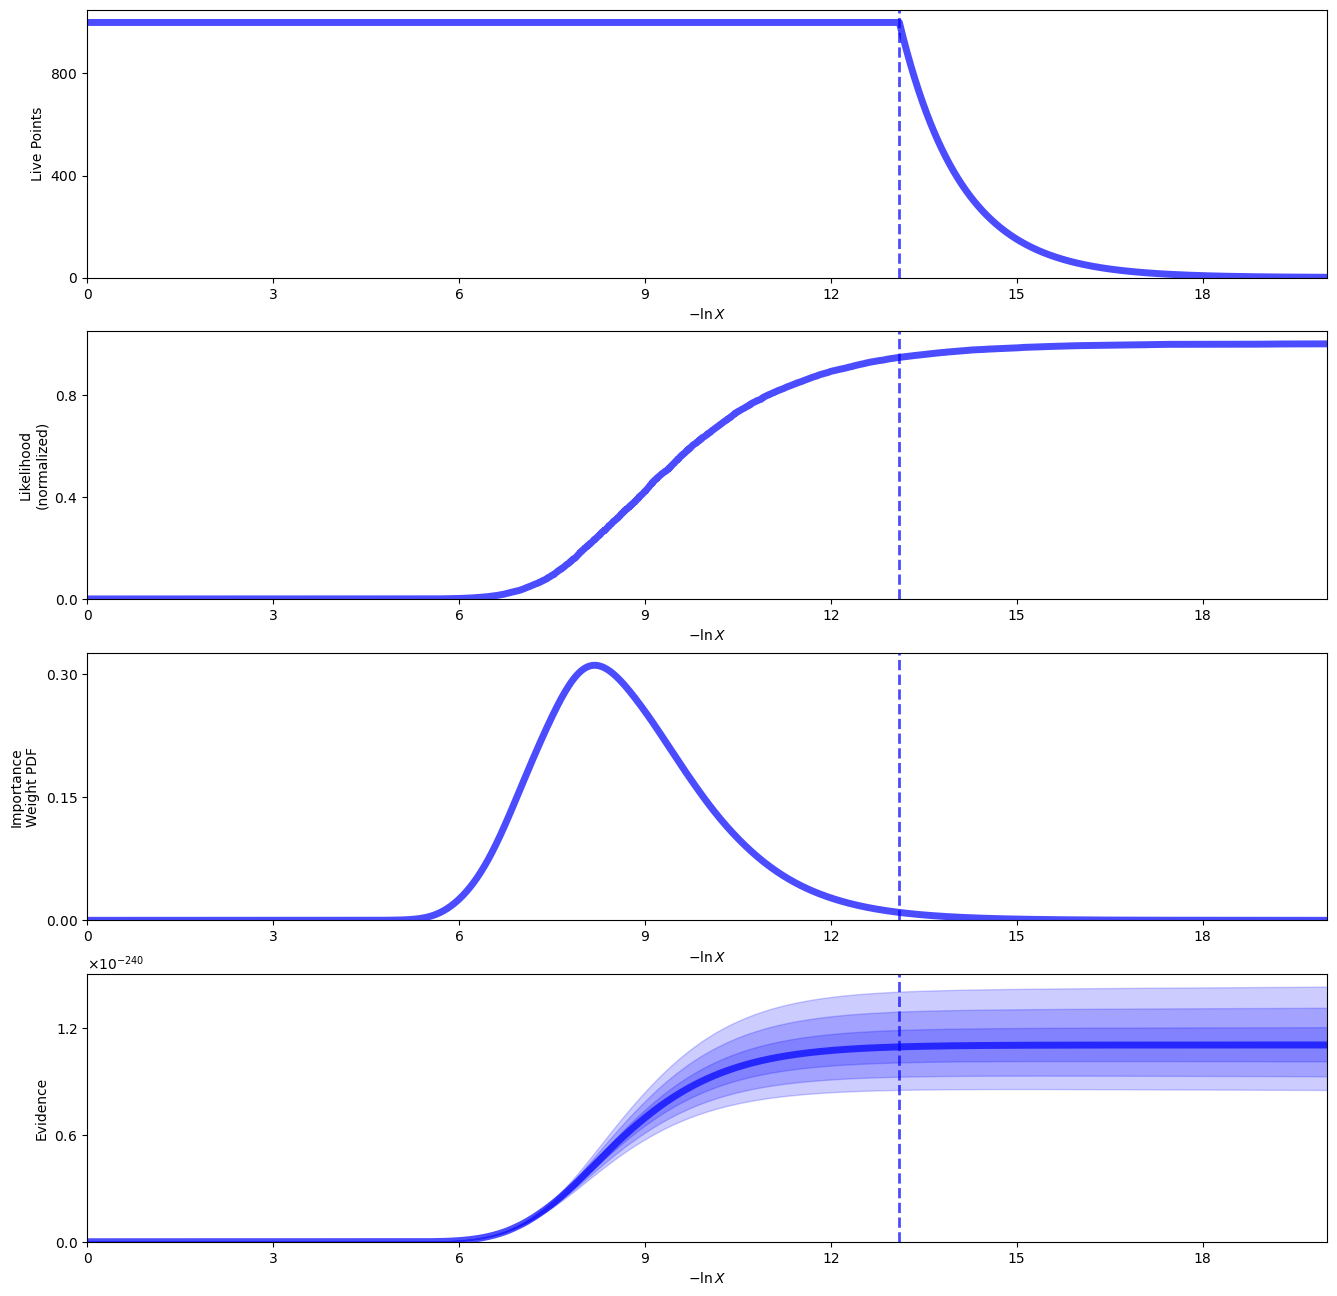

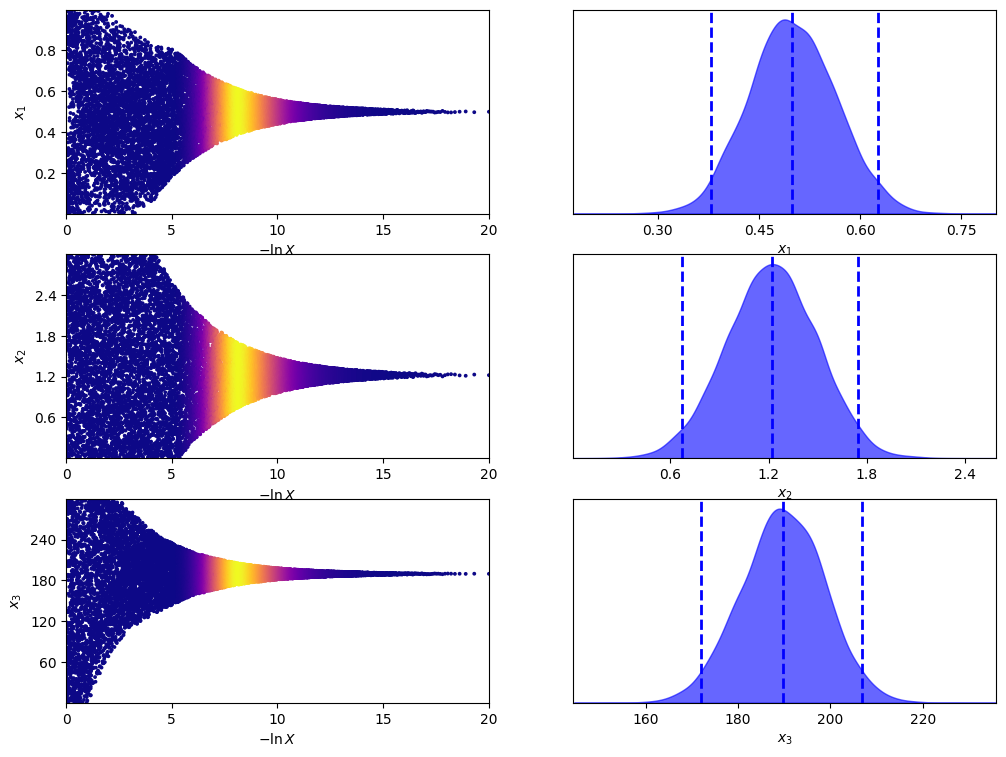

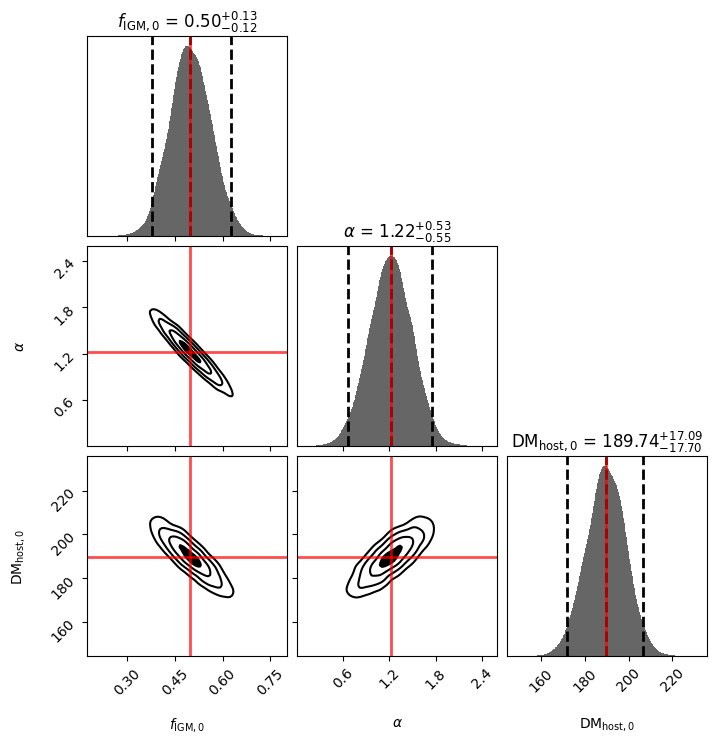

In [23]:
from dynesty import plotting as dyplot

# Runplot for time-dependent f_IGM model
rfig_timedep, raxes_timedep = dyplot.runplot(results_dynesty_timedep)

# Traceplot for time-dependent f_IGM model
tfig_timedep, taxes_timedep = dyplot.traceplot(results_dynesty_timedep)

# Get equally weighted samples from dynesty results for time-dependent f_IGM model
samples_timedep_dynesty = results_dynesty_timedep.samples_equal()

# Define truths from dynesty samples for time-dependent f_IGM model
f_med_timedep_dynesty = np.percentile(samples_timedep_dynesty[:, 0], 50)
alpha_med_timedep_dynesty = np.percentile(samples_timedep_dynesty[:, 1], 50)
D_med_timedep_dynesty = np.percentile(samples_timedep_dynesty[:, 2], 50)

# Cornerplot for time-dependent f_IGM model
dffig_timedep, dfaxes_timedep = dyplot.cornerplot(results_dynesty_timedep,
                                  labels=[r"$f_{\rm IGM,0}$", r"$\alpha$", r"$\mathrm{DM}_{\rm host,0}$"],
                                  truths=[f_med_timedep_dynesty, alpha_med_timedep_dynesty, D_med_timedep_dynesty],
                                  show_titles=True)


### Model Comparison Results

We compare the two models based on their Bayesian evidence values ($\mathcal{Z}$) calculated using `dynesty`. The difference in log-evidence $\Delta\, \ln\, \mathcal{Z}$ determines model preference via the Jeffreys scale.

In [24]:
# Retrieve final scalar log-evidence values and their errors from dynesty results
logz_const = results_dynesty_const.logz[-1]
logzerr_const = results_dynesty_const.logzerr[-1]

logz_timedep = results_dynesty_timedep.logz[-1]
logzerr_timedep = results_dynesty_timedep.logzerr[-1]

# Calculate the difference in log-evidence
Delta_ln_Z = logz_timedep - logz_const
Delta_ln_Z_err = np.sqrt(logzerr_const**2 + logzerr_timedep**2)

print(f"\n--- Model Comparison Results ---")
print(f"ln(Z_constant)     = {logz_const:.3f} +/- {logzerr_const:.3f}")
print(f"ln(Z_time-dependent) = {logz_timedep:.3f} +/- {logzerr_timedep:.3f}")
print(f"Delta ln(Z) (timedep - const) = {Delta_ln_Z:.3f} +/- {Delta_ln_Z_err:.3f}\n")

# Interpret using Jeffreys' Scale
if Delta_ln_Z < 1:
    interpretation = "inconclusive"
elif 1 <= Delta_ln_Z < 3:
    interpretation = "weak evidence for time-dependent model"
elif 3 <= Delta_ln_Z < 5:
    interpretation = "moderate evidence for time-dependent model"
else:
    interpretation = "strong evidence for time-dependent model"

print(f"Interpretation (Jeffreys' Scale): {interpretation}")


--- Model Comparison Results ---
ln(Z_constant)     = -560.909 +/- 0.080
ln(Z_time-dependent) = -552.521 +/- 0.087
Delta ln(Z) (timedep - const) = 8.388 +/- 0.118

Interpretation (Jeffreys' Scale): strong evidence for time-dependent model


## **5. SAVING**

In [25]:
# ---------------------------------------------------------------------------
# 5.1  MOUNT GOOGLE DRIVE + SETUP
# ---------------------------------------------------------------------------
import os, json
import h5py
from google.colab import drive

drive.mount("/content/drive")

PROJECT_DIR  = "/content/drive/MyDrive/frb_cosmology_thesis"
CHAINS_DIR   = os.path.join(PROJECT_DIR, "chains")
EVIDENCE_DIR = os.path.join(PROJECT_DIR, "evidence")

os.makedirs(CHAINS_DIR,   exist_ok=True)
os.makedirs(EVIDENCE_DIR, exist_ok=True)

print("Project  →", PROJECT_DIR)
print("Chains   →", CHAINS_DIR)
print("Evidence →", EVIDENCE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project  → /content/drive/MyDrive/frb_cosmology_thesis
Chains   → /content/drive/MyDrive/frb_cosmology_thesis/chains
Evidence → /content/drive/MyDrive/frb_cosmology_thesis/evidence


In [26]:
# ---------------------------------------------------------------------------
# 5.2  CASE A — constant f_IGM
# samples_const was computed in Section 3 (already burned-in and thinned)
# ---------------------------------------------------------------------------
with h5py.File(os.path.join(CHAINS_DIR, "lcdm_caseA.h5"), "w") as f:
    f.create_dataset("chain", data=samples_const)
    f.attrs["param_names"]  = ["f_IGM_0", "DM_host_0"]
    f.attrs["param_labels"] = [r"f_{\rm IGM,0}", r"\mathrm{DM}_{\rm host,0}"]
    f.attrs["logz"]         = float(logz_const)
    f.attrs["logzerr"]      = float(logzerr_const)
    f.attrs["note"]         = "burned-in and thinned emcee chain, LCDM Case A"

print("Saved: lcdm_caseA.h5")

Saved: lcdm_caseA.h5


In [27]:
# ---------------------------------------------------------------------------
# 5.3  CASE B — time-dependent f_IGM
# samples_timedep was computed in Section 3 (already burned-in and thinned)
# ---------------------------------------------------------------------------
with h5py.File(os.path.join(CHAINS_DIR, "lcdm_caseB.h5"), "w") as f:
    f.create_dataset("chain", data=samples_timedep)
    f.attrs["param_names"]  = ["f_IGM_0", "alpha", "DM_host_0"]
    f.attrs["param_labels"] = [r"f_{\rm IGM,0}", r"\alpha", r"\mathrm{DM}_{\rm host,0}"]
    f.attrs["logz"]         = float(logz_timedep)
    f.attrs["logzerr"]      = float(logzerr_timedep)
    f.attrs["note"]         = "burned-in and thinned emcee chain, LCDM Case B"

print("Saved: lcdm_caseB.h5")

Saved: lcdm_caseB.h5


In [28]:
# ---------------------------------------------------------------------------
# 5.4  BAYES EVIDENCE
# ---------------------------------------------------------------------------
entry = {
    "lcdm": {
        "case_A": {"logz": float(logz_const),   "logzerr": float(logzerr_const)},
        "case_B": {"logz": float(logz_timedep), "logzerr": float(logzerr_timedep)},
        "delta_lnZ_BvsA":     float(Delta_ln_Z),
        "delta_lnZ_BvsA_err": float(Delta_ln_Z_err),
    }
}

bayes_path = os.path.join(EVIDENCE_DIR, "bayes_evidence.json")
if os.path.exists(bayes_path):
    with open(bayes_path) as jf:
        existing = json.load(jf)
    existing.update(entry)
    entry = existing

with open(bayes_path, "w") as jf:
    json.dump(entry, jf, indent=2)

print("Saved: evidence/bayes_evidence.json")
print(json.dumps(entry, indent=2))

Saved: evidence/bayes_evidence.json
{
  "model_independent": {
    "case_A": {
      "logz": -560.5029264972775,
      "logzerr": 0.1978881268911515
    },
    "case_B": {
      "logz": -553.6351197594189,
      "logzerr": 0.22704803343448685
    },
    "delta_lnZ_BvsA": 6.8678067378585865,
    "delta_lnZ_BvsA_err": 0.30118187238105204
  },
  "lcdm": {
    "case_A": {
      "logz": -560.908909858381,
      "logzerr": 0.08017501071658768
    },
    "case_B": {
      "logz": -552.5211589836642,
      "logzerr": 0.08656340275996759
    },
    "delta_lnZ_BvsA": 8.387750874716744,
    "delta_lnZ_BvsA_err": 0.1179883682436083
  }
}
